# Predicción de precios con CatBoost
Notebook pedagógico para explicar la solución base de la competición **Predicción de prices de portátiles STEMIA 2025-09**.

## 1. Preparar el entorno
Importamos librerías y fijamos una semilla para reproducibilidad.

In [14]:
# Configuración de librerías y entorno
import os
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from catboost import CatBoostRegressor, Pool, cv
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'catboost', '--quiet'])
    from catboost import CatBoostRegressor, Pool, cv

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.titlesize'] = 12

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 2. Cargar datos
Leemos los CSV de entrenamiento y prueba y revisamos formas básicas.

In [15]:
# Cargamos los CSV de la competición

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

TARGET = 'Price_euros'
feature_cols = [c for c in train_df.columns if c != TARGET]

# Definimos columnas predictoras y target

Train shape: (912, 14)
Test shape: (391, 13)


### Primer vistazo a los datos

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,697,705,Asus,Chromebook Flip,2 in 1 Convertible,12.5,Full HD / Touchscreen 1920x1080,Intel Core M M3-6Y30 0.9GHz,4GB,64GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.2kg,669.0
1,435,442,Asus,Rog Strix,Gaming,17.3,Full HD 1920x1080,AMD Ryzen 1600 3.2GHz,8GB,256GB SSD + 1TB HDD,AMD Radeon RX 580,Windows 10,3.2kg,1695.0
2,735,743,Lenovo,V310-15IKB (i7-7500U/4GB/1TB/FHD/W10),Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,4GB,1TB HDD,Intel HD Graphics 620,Windows 10,1.85kg,779.0
3,864,875,Dell,XPS 13,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 7660U 2.5GHz,16GB,512GB SSD,Intel Iris Plus Graphics 640,Windows 10,1.29kg,2240.0
4,1176,1194,Lenovo,B51-80 (i7-6500U/4GB/1008GB/FHD/W7),Notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,1.0TB Hybrid,Intel HD Graphics 520,Windows 7,2.32kg,825.0


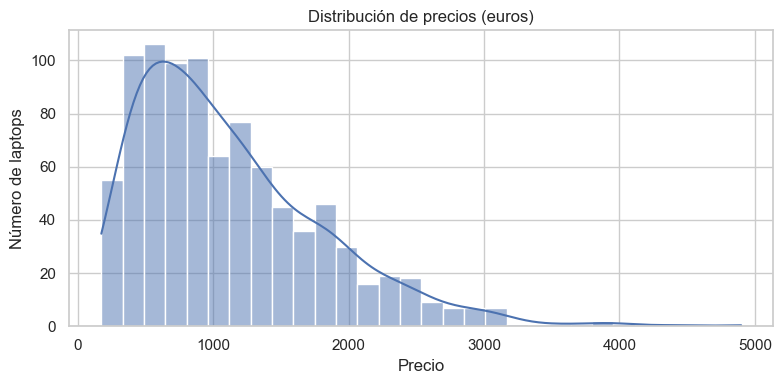

In [16]:
# Mostramos un sample de filas y la distribución del precio
display(train_df.head())

plt.figure()
sns.histplot(train_df['Price_euros'], bins=30, kde=True)
plt.title('Distribución de precios (euros)')
plt.xlabel('Precio')
plt.ylabel('Número de laptops')
plt.tight_layout()
plt.show()


### 2.1 ¿Qué portátiles son más frecuentes?
Revisamos el número de equipos y el precio medio por tipo de portátil para contextualizar la tarea.

,media_precio,cantidad
TypeName,,
Workstation,2330.798182,22
Gaming,1743.393077,143
Ultrabook,1559.773231,130
2 in 1 Convertible,1274.018810,84
Notebook,788.099961,516
Netbook,630.641176,17


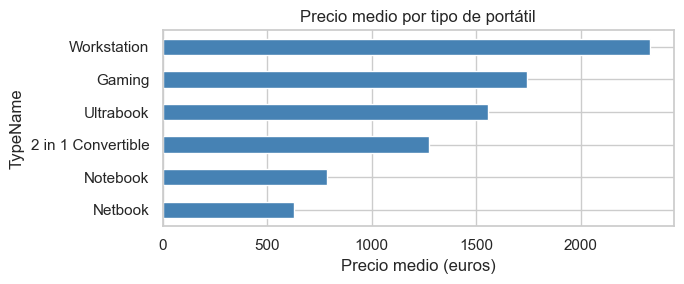

In [17]:
# Resumen de tipos de portátil y precio medio
type_summary = (
    train_df.groupby('TypeName')['Price_euros']
            .agg(media_precio='mean', cantidad='count')
            .sort_values('media_precio', ascending=False)
)
display(type_summary)

plt.figure(figsize=(7, 3))
type_summary['media_precio'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Precio medio por tipo de portátil')
plt.xlabel('Precio medio (euros)')
plt.tight_layout()
plt.show()


## 3. Ingeniería de características
Transformamos texto en variables numéricas y categóricas útiles para CatBoost.

In [18]:
import re

# ---- Funciones auxiliares para convertir texto en atributos ----

PRODUCT_FLAG_PATTERNS = {
    'Product_is_Gaming': 'gaming',
    'Product_is_Chromebook': 'chromebook',
    'Product_is_Pro': 'pro',
    'Product_is_Yoga': 'yoga',
    'Product_is_Thinkpad': 'thinkpad',
    'Product_is_Vivobook': 'vivobook'
}


def safe_ratio(numerator, denominator, fill_value=0.0):
    ratio = numerator / denominator.replace({0: np.nan})
    return ratio.replace([np.inf, -np.inf], np.nan).fillna(fill_value)


def parse_memory(cell: str) -> pd.Series:
    # Convierte cadenas como '256GB SSD + 1TB HDD' en columnas numericas
    values = {'HDD': 0, 'SSD': 0, 'Hybrid': 0, 'Flash': 0, 'Other': 0}
    if pd.isna(cell):
        values['Total_Storage'] = 0
        return pd.Series(values)
    for part in str(cell).split('+'):
        part = part.strip()
        match = re.search(r'(\d+)(TB|GB)', part)
        if not match:
            continue  # ignoramos segmentos sin informacion numerica
        size = int(match.group(1))
        unit = match.group(2)
        size_gb = size * 1024 if unit == 'TB' else size
        lower = part.lower()
        if 'ssd' in lower:
            values['SSD'] += size_gb
        elif 'hdd' in lower:
            values['HDD'] += size_gb
        elif 'hybrid' in lower:
            values['Hybrid'] += size_gb
        elif 'flash' in lower or 'emmc' in lower:
            values['Flash'] += size_gb
        else:
            values['Other'] += size_gb
    values['Total_Storage'] = sum(values.values())
    return pd.Series(values)


def simplify_os(name: str) -> str:
    # Agrupa sistemas operativos en categorias simples
    if pd.isna(name):
        return 'Other'
    name = name.lower()
    if 'windows' in name:
        return 'Windows'
    if 'mac' in name or 'os x' in name:
        return 'MacOS'
    if 'linux' in name:
        return 'Linux'
    if 'chrome' in name:
        return 'ChromeOS'
    if 'no os' in name:
        return 'NoOS'
    if 'android' in name:
        return 'Android'
    return 'Other'


def cpu_main_series(text: str) -> str:
    # Identifica la familia principal del procesador
    t = str(text).lower()
    if 'xeon' in t:
        return 'Xeon'
    if 'ryzen 9' in t:
        return 'Ryzen9'
    if 'ryzen 7' in t:
        return 'Ryzen7'
    if 'ryzen 5' in t:
        return 'Ryzen5'
    if 'ryzen 3' in t:
        return 'Ryzen3'
    if 'core i9' in t:
        return 'Core_i9'
    if 'core i7' in t:
        return 'Core_i7'
    if 'core i5' in t:
        return 'Core_i5'
    if 'core i3' in t:
        return 'Core_i3'
    if 'celeron' in t:
        return 'Celeron'
    if 'pentium' in t:
        return 'Pentium'
    if 'atom' in t:
        return 'Atom'
    if 'a12' in t:
        return 'A12'
    if 'a9' in t:
        return 'A9'
    return 'OtherCPU'


def cpu_suffix(text: str) -> str:
    # Extrae sufijos como U, HQ, HK que indican gama
    match = re.search(r'(\d{3,4})([A-Za-z]+)', str(text))
    if match:
        return match.group(2).upper()
    return 'NA'


def gpu_main_series(text: str) -> str:
    # Agrupa GPUs por familia (RTX, GTX, MX, Radeon, etc.)
    t = str(text).lower()
    if 'quadro' in t:
        return 'Quadro'
    if 'rtx' in t:
        return 'RTX'
    if 'gtx' in t:
        return 'GTX'
    if 'mx' in t:
        return 'MX'
    if 'radeon rx' in t:
        return 'RadeonRX'
    if 'radeon' in t:
        return 'Radeon'
    if 'iris' in t:
        return 'Iris'
    if 'uhd' in t or 'hd graphics' in t:
        return 'Intel_HD_UHD'
    return 'OtherGPU'


def res_category(x: float, y: float) -> str:
    # Clasifica la resolucion: HD / FHD / QHD / 4K
    if pd.isna(x) or pd.isna(y):
        return 'UnknownRes'
    x = int(x)
    y = int(y)
    if (x >= 3800 and y >= 2100) or '2160' in f"{y}":
        return 'UHD_4K'
    if (x >= 2500 and y >= 1400):
        return 'QHD'
    if (x >= 1900 and y >= 1080):
        return 'FHD'
    if (x <= 1366 and y <= 768):
        return 'HD'
    return 'OtherRes'


def aspect_ratio(x: float, y: float) -> float:
    # Relacion ancho/alto (por ejemplo 1.78 ~ 16:9)
    if pd.isna(x) or pd.isna(y) or y == 0:
        return np.nan
    return round(float(x) / float(y), 3)


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    # Genera todas las columnas numericas y categoricas necesarias
    data = df.copy()

    # Conversion basica
    data['Ram_GB'] = pd.to_numeric(data['Ram'].str.replace('GB', '', regex=False), errors='coerce')
    data['Weight_kg'] = pd.to_numeric(data['Weight'].str.replace('kg', '', regex=False), errors='coerce')

    # Indicadores de pantalla
    data['Touchscreen'] = data['ScreenResolution'].str.contains('Touchscreen', case=False, na=False).astype(int)
    data['IPS'] = data['ScreenResolution'].str.contains('IPS', case=False, na=False).astype(int)
    data['Retina'] = data['ScreenResolution'].str.contains('Retina', case=False, na=False).astype(int)

    # Resolucion y metricas relacionadas
    resolution = data['ScreenResolution'].str.extract(r'(?P<ResX>\d+)\s*x\s*(?P<ResY>\d+)')
    data['ResX'] = pd.to_numeric(resolution['ResX'], errors='coerce')
    data['ResY'] = pd.to_numeric(resolution['ResY'], errors='coerce')
    data['PPI'] = ((data['ResX']**2 + data['ResY']**2)**0.5 / data['Inches']).round(2)
    data['ResCategory'] = [res_category(x, y) for x, y in zip(data['ResX'], data['ResY'])]
    data['Aspect'] = [aspect_ratio(x, y) for x, y in zip(data['ResX'], data['ResY'])]
    data['Is4K'] = (data['ResCategory'] == 'UHD_4K').astype(int)
    data['IsFHD'] = (data['ResCategory'] == 'FHD').astype(int)
    data['HighPPI'] = (data['PPI'] >= 200).astype(int)

    # Simplificacion de CPU y GPU
    data['Cpu_brand'] = data['Cpu'].str.split().str[0]
    data['Cpu_family'] = data['Cpu'].str.extract(r"(^[A-Za-z]+\s+[A-Za-z0-9\-]+)")[0]
    data['Cpu_speed_GHz'] = pd.to_numeric(data['Cpu'].str.extract(r'(\d+\.?\d*)GHz')[0], errors='coerce')
    data['Cpu_main'] = data['Cpu'].apply(cpu_main_series)
    data['Cpu_suffix'] = data['Cpu'].apply(cpu_suffix)
    data['Cpu_code'] = pd.to_numeric(data['Cpu'].str.extract(r'(\d{3,5})')[0], errors='coerce')
    data['Cpu_cores'] = pd.to_numeric(data['Cpu'].str.extract(r'(\d+)\s*[Cc]ore')[0], errors='coerce')
    data['Cpu_threads'] = pd.to_numeric(data['Cpu'].str.extract(r'(\d+)\s*[Tt]hread')[0], errors='coerce')
    data['Gpu_brand'] = data['Gpu'].str.split().str[0]
    data['Gpu_main'] = data['Gpu'].apply(gpu_main_series)
    data['Gpu_code'] = pd.to_numeric(data['Gpu'].str.extract(r'(\d{3,4})')[0], errors='coerce')
    data['DiscreteGPU'] = data['Gpu_brand'].isin(['Nvidia', 'AMD']).astype(int)
    data['HighEndCPU'] = data['Cpu_main'].isin(['Core_i9', 'Core_i7', 'Ryzen9', 'Ryzen7']).astype(int)

    # Memoria detallada y senales adicionales
    memory_expanded = data['Memory'].apply(parse_memory)
    data = pd.concat([data, memory_expanded], axis=1)
    storage_cols = ['HDD', 'SSD', 'Hybrid', 'Flash']
    data['Has_DualStorage'] = (memory_expanded[storage_cols] > 0).sum(axis=1).gt(1).astype(int)
    data['SSD_Ratio'] = safe_ratio(data['SSD'], data['Total_Storage'])

    # Simplificamos OS y anadimos informacion de tamano
    data['OpSys_simplified'] = data['OpSys'].apply(simplify_os)
    data['Lightweight'] = (data['Weight_kg'] < 1.5).astype(int)
    data['SizeClass'] = pd.cut(data['Inches'], bins=[0, 13.5, 15.1, 100], labels=['Small', 'Medium', 'Large'], include_lowest=True)

    # Caracteristicas adicionales derivadas
    data['Product_family'] = data['Product'].str.extract(r'^([A-Za-z]+)')[0]
    product_lower = data['Product'].str.lower()
    for col, pattern in PRODUCT_FLAG_PATTERNS.items():
        data[col] = product_lower.str.contains(pattern, na=False).astype(int)
    data['Storage_GB_per_kg'] = safe_ratio(data['Total_Storage'], data['Weight_kg'] + 1e-3)
    data['Ram_per_kg'] = safe_ratio(data['Ram_GB'], data['Weight_kg'] + 1e-3)
    data['PPIxTouch'] = data['PPI'] * (1 + data['Touchscreen'])

    # Quitamos columnas originales ya procesadas
    drop_cols = ['Ram', 'Weight', 'ScreenResolution', 'Cpu', 'Gpu', 'Memory', 'OpSys', 'id', 'laptop_ID']
    data = data.drop(columns=[col for col in drop_cols if col in data.columns])

    # Relleno final de valores faltantes
    numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
    data[numeric_cols] = data[numeric_cols].fillna(0)

    # Convertimos columnas categoricas a texto antes de rellenar con 'Unknown'
    cat_cols_internal = data.select_dtypes(include=['category']).columns
    if len(cat_cols_internal) > 0:
        data[cat_cols_internal] = data[cat_cols_internal].astype(str).replace('nan', 'Unknown')

    data = data.fillna('Unknown')

    return data


In [19]:
# Aplicamos la ingeniería de características y comprobamos el tamaño resultante
train_X = engineer_features(train_df[feature_cols])
test_X = engineer_features(test_df[feature_cols])
y = train_df[TARGET]

print(f"Train features: {train_X.shape}")
print(f"Test features: {test_X.shape}")


Train features: (912, 51)
Test features: (391, 51)


In [20]:
# Estratificamos el target y aplicamos target encoding regularizado
NUM_BINS = min(10, max(2, len(np.unique(y)) - 1))
price_bins = pd.qcut(y, q=NUM_BINS, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
folds = list(skf.split(train_X, price_bins))


def add_target_encodings(train_df, test_df, target, columns, folds, min_samples_leaf=20, smoothing=10.0):
    prior = target.mean()
    for col in columns:
        oof_values = np.zeros(len(train_df))
        test_fold_values = np.zeros((len(test_df), len(folds)))
        for fold_idx, (tr_idx, va_idx) in enumerate(folds):
            tr_series = train_df.iloc[tr_idx][col]
            va_series = train_df.iloc[va_idx][col]
            target_tr = target.iloc[tr_idx]
            stats = (
                pd.DataFrame({'feature': tr_series, 'target': target_tr})
                .groupby('feature')['target']
                .agg(['mean', 'count'])
            )
            smoothing_factor = 1 / (1 + np.exp(-(stats['count'] - min_samples_leaf) / smoothing))
            stats['encoding'] = prior * (1 - smoothing_factor) + stats['mean'] * smoothing_factor
            mapping = stats['encoding']
            oof_values[va_idx] = va_series.map(mapping).fillna(prior).to_numpy()
            test_fold_values[:, fold_idx] = test_df[col].map(mapping).fillna(prior).to_numpy()
        train_df[f'{col}_te'] = oof_values
        test_df[f'{col}_te'] = test_fold_values.mean(axis=1)
    return train_df, test_df


target_encoding_cols = ['Company', 'Product', 'Product_family', 'Cpu_main', 'Gpu_main', 'OpSys_simplified', 'TypeName']
train_X, test_X = add_target_encodings(train_X, test_X, y, target_encoding_cols, folds)


In [21]:
# CatBoost necesita saber que columnas son categoricas
cat_features = [
    'Company',
    'Product',
    'Product_family',
    'TypeName',
    'Cpu_brand',
    'Cpu_family',
    'Cpu_main',
    'Cpu_suffix',
    'Gpu_brand',
    'Gpu_main',
    'OpSys_simplified',
    'ResCategory',
    'SizeClass'
]

missing_cat = [col for col in cat_features if col not in train_X.columns]
if missing_cat:
    raise KeyError(f"Faltan columnas categoricas esperadas: {missing_cat}")


## 4. Columnas categóricas
Indicamos a CatBoost qué columnas tratar como categorías.

In [22]:
# Busqueda de hiperparametros con validacion estratificada y OOF
import random

base_params = {
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_seed': RANDOM_SEED,
    'allow_writing_files': False,
    'early_stopping_rounds': 100
}

param_choices = {
    'depth': [6, 7, 8, 9],
    'learning_rate': [0.03, 0.04, 0.05, 0.06, 0.08],
    'l2_leaf_reg': [3, 6, 8, 12, 20, 30],
    'random_strength': [0.3, 0.6, 0.9, 1.2, 1.8],
    'bagging_temperature': [0.0, 0.5, 1.0, 2.0, 3.0],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'rsm': [0.7, 0.8, 0.9, 1.0],
    'iterations': [1400, 1600, 1800, 2000, 2200]
}

random.seed(RANDOM_SEED)
search_results = []
NUM_SEARCH = 12

print(f"Evaluando {NUM_SEARCH} configuraciones aleatorias...")
for run_idx in range(NUM_SEARCH):
    spec = {
        'depth': random.choice(param_choices['depth']),
        'learning_rate': random.choice(param_choices['learning_rate']),
        'l2_leaf_reg': random.choice(param_choices['l2_leaf_reg']),
        'random_strength': random.choice(param_choices['random_strength']),
        'rsm': random.choice(param_choices['rsm']),
        'iterations': random.choice(param_choices['iterations'])
    }
    bootstrap_type = random.choice(['Bayesian', 'Bernoulli'])
    spec['bootstrap_type'] = bootstrap_type
    if bootstrap_type == 'Bayesian':
        spec['bagging_temperature'] = random.choice(param_choices['bagging_temperature'])
    else:
        spec['subsample'] = random.choice(param_choices['subsample'])

    params = dict(base_params)
    params.update(spec)
    iterations = params.pop('iterations')
    params['iterations'] = iterations
    if params.get('bootstrap_type') != 'Bayesian':
        params.pop('bagging_temperature', None)
    if params.get('bootstrap_type') != 'Bernoulli':
        params.pop('subsample', None)

    oof_preds = np.zeros(len(train_X))
    fold_maes = []
    best_iters = []

    for fold_idx, (tr_idx, va_idx) in enumerate(folds):
        X_tr, X_va = train_X.iloc[tr_idx], train_X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
        valid_pool = Pool(X_va, y_va, cat_features=cat_features)

        params_fold = dict(params)
        params_fold['random_seed'] = RANDOM_SEED + fold_idx

        model = CatBoostRegressor(**params_fold)
        model.fit(train_pool, eval_set=valid_pool, verbose=False, use_best_model=True)
        best_iter = model.get_best_iteration()
        if best_iter is None or best_iter <= 0:
            best_iter = params_fold['iterations']
        best_iters.append(best_iter)

        preds = model.predict(valid_pool)
        oof_preds[va_idx] = preds
        fold_mae = mean_absolute_error(y_va, preds)
        fold_maes.append(fold_mae)

    overall_mae = mean_absolute_error(y, oof_preds)
    result = {
        'run': run_idx + 1,
        'params': params,
        'mean_fold_mae': float(np.mean(fold_maes)),
        'std_fold_mae': float(np.std(fold_maes)),
        'oof_mae': float(overall_mae),
        'best_iteration_mean': int(np.mean(best_iters))
    }
    search_results.append(result)
    print(f"Run {run_idx + 1:02d} - OOF MAE: {overall_mae:.3f} | mean fold MAE: {np.mean(fold_maes):.3f}")

cv_results = pd.DataFrame(search_results).sort_values('oof_mae').reset_index(drop=True)
best_row = cv_results.iloc[0]
best_params = dict(best_row['params'])
best_iterations = int(best_row['best_iteration_mean'])

print("Mejor configuracion encontrada (por OOF MAE):")
print(best_params)
print(f"Iteraciones medias sugeridas: {best_iterations}")
cv_results


Evaluando 12 configuraciones aleatorias...
Run 01 - OOF MAE: 157.561 | mean fold MAE: 157.577
Run 02 - OOF MAE: 159.891 | mean fold MAE: 159.899
Run 03 - OOF MAE: 159.593 | mean fold MAE: 159.608
Run 04 - OOF MAE: 156.496 | mean fold MAE: 156.520
Run 05 - OOF MAE: 158.819 | mean fold MAE: 158.837
Run 06 - OOF MAE: 160.113 | mean fold MAE: 160.123
Run 07 - OOF MAE: 157.642 | mean fold MAE: 157.661
Run 08 - OOF MAE: 162.615 | mean fold MAE: 162.634
Run 09 - OOF MAE: 160.418 | mean fold MAE: 160.439
Run 10 - OOF MAE: 166.356 | mean fold MAE: 166.378
Run 11 - OOF MAE: 164.302 | mean fold MAE: 164.319
Run 12 - OOF MAE: 164.347 | mean fold MAE: 164.363
Mejor configuracion encontrada (por OOF MAE):
{'loss_function': 'MAE', 'eval_metric': 'MAE', 'random_seed': 42, 'allow_writing_files': False, 'early_stopping_rounds': 100, 'depth': 6, 'learning_rate': 0.04, 'l2_leaf_reg': 30, 'random_strength': 1.2, 'rsm': 0.9, 'bootstrap_type': 'Bayesian', 'bagging_temperature': 0.5, 'iterations': 1800}
Itera

,run,params,mean_fold_mae,std_fold_mae,oof_mae,best_iteration_mean
0,4,"{'loss_function': 'MAE', 'eval_metric': 'MAE',...",156.520500,10.618970,156.496035,806
1,1,"{'loss_function': 'MAE', 'eval_metric': 'MAE',...",157.577383,7.758976,157.561429,966
2,7,"{'loss_function': 'MAE', 'eval_metric': 'MAE',...",157.660760,9.194737,157.642319,772
3,5,"{'loss_function': 'MAE', 'eval_metric': 'MAE',...",158.836827,8.539592,158.818898,739
4,3,"{'loss_function': 'MAE', 'eval_metric': 'MAE',...",159.607742,8.509765,159.593488,383
5,2,"{'loss_function': 'MAE', 'eval_metric': 'MAE',...",159.898777,5.225569,159.891323,393
6,6,"{'loss_function': 'MAE', 'eval_metric': 'MAE',...",160.123363,9.707882,160.112772,523
7,9,"{'loss_function': 'MAE', 'eval_metric': 'MAE',...",160.439055,10.893237,160.417589,707
8,8,"{'loss_function': 'MAE', 'eval_metric': 'MAE',...",162.633636,8.550820,162.614741,454
9,11,"{'loss_function': 'MAE', 'eval_metric': 'MAE',...",164.319032,9.167834,164.301667,371


## 5. Búsqueda sencilla de hiperparámetros
Usamos `catboost.cv` para elegir profundidad, learning rate y regularización con 5-fold MAE.

In [23]:
# Validación cruzada con CatBoost (5 folds)
# Probamos combinaciones sencillas de hiperparámetros y registramos el MAE
base_params = {
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_seed': RANDOM_SEED,
    'allow_writing_files': False
}

search_space = [
    {'name': 'depth6_lr060', 'params': {'depth': 6, 'learning_rate': 0.060, 'l2_leaf_reg': 6, 'bagging_temperature': 0.7, 'random_strength': 0.8}, 'iterations': 1600},
    {'name': 'depth7_lr050', 'params': {'depth': 7, 'learning_rate': 0.050, 'l2_leaf_reg': 8, 'bagging_temperature': 0.8, 'random_strength': 1.0}, 'iterations': 2000},
    {'name': 'depth8_lr045', 'params': {'depth': 8, 'learning_rate': 0.045, 'l2_leaf_reg': 9, 'bagging_temperature': 0.9, 'random_strength': 1.1}, 'iterations': 2200},
    {'name': 'depth7_lr040', 'params': {'depth': 7, 'learning_rate': 0.040, 'l2_leaf_reg': 12, 'subsample': 0.85, 'rsm': 0.85, 'bootstrap_type': 'Bernoulli'}, 'iterations': 2400},
    {'name': 'depth8_lr035', 'params': {'depth': 8, 'learning_rate': 0.035, 'l2_leaf_reg': 14, 'subsample': 0.80, 'rsm': 0.80, 'bootstrap_type': 'Bernoulli'}, 'iterations': 2600}
]

train_pool = Pool(train_X, y, cat_features=cat_features)
cv_rows = []

print("Ejecutando validación cruzada (5 folds)...")
for spec in search_space:
    params = base_params | spec['params']
    params['iterations'] = spec['iterations']
    if params.get('bootstrap_type', 'Bayesian') != 'Bayesian':
        params.pop('bagging_temperature', None)

    cv_result = cv(
        train_pool,
        params,
        fold_count=5,
        partition_random_seed=RANDOM_SEED,
        shuffle=True,
        verbose=False
    )

    best_iter = int(cv_result['test-MAE-mean'].idxmin())
    best_mae = float(cv_result['test-MAE-mean'].iloc[best_iter])
    cv_rows.append({
        'config': spec['name'],
        'params': spec['params'],
        'best_iteration': best_iter + 1,
        'mae': best_mae
    })
    print(f"  {spec['name']}: MAE = {best_mae:.3f} en iteración {best_iter + 1}")

cv_results = pd.DataFrame(cv_rows).sort_values('mae').reset_index(drop=True)

best_row = cv_results.iloc[0]
best_params = base_params | best_row['params']
best_iterations = int(best_row['best_iteration'])

print("Configuración seleccionada:", best_row['config'])
print(f"MAE CV: {best_row['mae']:.3f}  | Iteraciones óptimas: {best_iterations}")
cv_results

Ejecutando validación cruzada (5 folds)...
Training on fold [0/5]

bestTest = 171.7767973
bestIteration = 1268

Training on fold [1/5]

bestTest = 165.0096343
bestIteration = 1157

Training on fold [2/5]

bestTest = 140.0566818
bestIteration = 1598

Training on fold [3/5]

bestTest = 147.2175833
bestIteration = 1547

Training on fold [4/5]

bestTest = 142.5771185
bestIteration = 1265

  depth6_lr060: MAE = 153.713 en iteración 1585
Training on fold [0/5]

bestTest = 178.6104621
bestIteration = 1412

Training on fold [1/5]

bestTest = 162.0824075
bestIteration = 1380

Training on fold [2/5]

bestTest = 141.0314736
bestIteration = 1968

Training on fold [3/5]

bestTest = 140.3735882
bestIteration = 1926

Training on fold [4/5]

bestTest = 142.4963218
bestIteration = 1259

  depth7_lr050: MAE = 153.337 en iteración 1920
Training on fold [0/5]

bestTest = 175.1924531
bestIteration = 2125

Training on fold [1/5]

bestTest = 173.7717962
bestIteration = 2190

Training on fold [2/5]

bestTest 

,config,params,best_iteration,mae
0,depth7_lr040,"{'depth': 7, 'learning_rate': 0.04, 'l2_leaf_r...",2168,152.006665
1,depth7_lr050,"{'depth': 7, 'learning_rate': 0.05, 'l2_leaf_r...",1920,153.336526
2,depth6_lr060,"{'depth': 6, 'learning_rate': 0.06, 'l2_leaf_r...",1585,153.713133
3,depth8_lr035,"{'depth': 8, 'learning_rate': 0.035, 'l2_leaf_...",2214,153.866701
4,depth8_lr045,"{'depth': 8, 'learning_rate': 0.045, 'l2_leaf_...",2185,154.906734


### Importancia de características
Visualizamos qué variables influyen más en las predicciones para apoyar la explicación.

## 6. Entrenamiento final y mezcla logarítmica
Entrenamos CatBoost sobre el set completo, repetimos con target log-transformado y encontramos el peso óptimo del blend mediante búsqueda dorada.

In [24]:
# Entrenamos CatBoost con OOF y mezcla basada en validacion
from math import sqrt

final_params = dict(best_params)
final_iterations = max(600, best_iterations)

standard_oof = np.zeros(len(train_X))
log_oof = np.zeros(len(train_X))
fold_best_iters = []

print('Generando predicciones OOF para modelo base y log-transformado...')
for fold_idx, (tr_idx, va_idx) in enumerate(folds):
    X_tr, X_va = train_X.iloc[tr_idx], train_X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    valid_pool = Pool(X_va, y_va, cat_features=cat_features)

    params_fold = dict(final_params)
    params_fold['iterations'] = final_iterations
    params_fold['random_seed'] = RANDOM_SEED + fold_idx

    model = CatBoostRegressor(**params_fold)
    model.fit(train_pool, eval_set=valid_pool, verbose=100, use_best_model=True)
    best_iter = model.get_best_iteration()
    if best_iter is None or best_iter <= 0:
        best_iter = params_fold['iterations']
    fold_best_iters.append(best_iter)

    standard_oof[va_idx] = model.predict(valid_pool)

    log_params_fold = dict(final_params)
    log_params_fold['loss_function'] = 'RMSE'
    log_params_fold['eval_metric'] = 'RMSE'
    log_params_fold['iterations'] = max(800, best_iter // 2)
    log_params_fold['random_seed'] = RANDOM_SEED + 100 + fold_idx

    train_pool_log = Pool(X_tr, np.log1p(y_tr), cat_features=cat_features)
    valid_pool_log = Pool(X_va, np.log1p(y_va), cat_features=cat_features)

    model_log = CatBoostRegressor(**log_params_fold)
    model_log.fit(train_pool_log, eval_set=valid_pool_log, verbose=100, use_best_model=True)

    log_oof[va_idx] = np.expm1(model_log.predict(valid_pool))

standard_oof_mae = mean_absolute_error(y, standard_oof)
log_oof_mae = mean_absolute_error(y, log_oof)

print(f'OOF MAE modelo base: {standard_oof_mae:.3f}')
print(f'OOF MAE modelo log:  {log_oof_mae:.3f}')


def golden_section_search(f, left=0.0, right=1.0, tol=1e-4):
    phi = (1 + sqrt(5)) / 2
    resphi = 2 - phi
    c = right - (right - left) * resphi
    d = left + (right - left) * resphi
    fc = f(c)
    fd = f(d)
    while abs(right - left) > tol:
        if fc < fd:
            right, d, fd = d, c, fc
            c = right - (right - left) * resphi
            fc = f(c)
        else:
            left, c, fc = c, d, fd
            d = left + (right - left) * resphi
            fd = f(d)
    return (left + right) / 2

blend_weight = golden_section_search(
    lambda w: mean_absolute_error(y, w * log_oof + (1 - w) * standard_oof)
)
blended_oof = blend_weight * log_oof + (1 - blend_weight) * standard_oof
blended_oof_mae = mean_absolute_error(y, blended_oof)

print(f'OOF MAE blend: {blended_oof_mae:.3f} (peso log = {blend_weight:.3f})')

final_iterations = int(np.mean(fold_best_iters))
print(f'Iteraciones finales (media folds): {final_iterations}')

feature_importances = []
standard_train_preds = []
standard_test_preds = []
log_train_preds = []
log_test_preds = []
seeds = [42, 2024, 1337]

full_train_pool = Pool(train_X, y, cat_features=cat_features)
full_train_pool_log = Pool(train_X, np.log1p(y), cat_features=cat_features)

print('Entrenando ensemble final en todo el entrenamiento...')
for seed in seeds:
    params_seed = dict(final_params)
    params_seed['iterations'] = final_iterations
    params_seed['random_seed'] = seed
    model = CatBoostRegressor(**params_seed)
    model.fit(full_train_pool, verbose=100)

    standard_train_preds.append(model.predict(train_X))
    standard_test_preds.append(model.predict(test_X))
    feature_importances.append(model.get_feature_importance(full_train_pool))

    log_params_seed = dict(final_params)
    log_params_seed['loss_function'] = 'RMSE'
    log_params_seed['eval_metric'] = 'RMSE'
    log_params_seed['iterations'] = max(800, final_iterations // 2)
    log_params_seed['random_seed'] = seed + 1000

    model_log = CatBoostRegressor(**log_params_seed)
    model_log.fit(full_train_pool_log, verbose=100)

    log_train_preds.append(np.expm1(model_log.predict(train_X)))
    log_test_preds.append(np.expm1(model_log.predict(test_X)))

standard_train_pred = np.mean(standard_train_preds, axis=0)
standard_test_pred = np.mean(standard_test_preds, axis=0)
log_train_pred = np.mean(log_train_preds, axis=0)
log_test_pred = np.mean(log_test_preds, axis=0)

cat_train_pred = blend_weight * log_train_pred + (1 - blend_weight) * standard_train_pred
cat_test_pred = blend_weight * log_test_pred + (1 - blend_weight) * standard_test_pred

train_mae_full = mean_absolute_error(y, cat_train_pred)
print(f'MAE en train (ensemble completo): {train_mae_full:.3f}')

importance_values = np.mean(feature_importances, axis=0)
importance_df = (
    pd.DataFrame({'feature': train_X.columns, 'importance': importance_values})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print('Guardando sumision final...')
submission = pd.DataFrame({'id': test_df['id'], 'Price_euros': cat_test_pred})
submission_path = Path('/kaggle/working/submission_catboost.csv') if Path('/kaggle').exists() else Path('submission_catboost.csv')
submission.to_csv(submission_path, index=False)
print(f'Archivo generado: {submission_path.resolve()}')
print(f'Precio minimo/maximo previsto: {cat_test_pred.min():.0f} - {cat_test_pred.max():.0f} EUR')
print(f'Precio medio previsto: {cat_test_pred.mean():.0f} EUR')


Generando predicciones OOF para modelo base y log-transformado...
0:	learn: 517.7945539	test: 508.0836753	best: 508.0836753 (0)	total: 25.6ms	remaining: 55.4s
100:	learn: 147.8549650	test: 184.0623439	best: 184.0623439 (100)	total: 4.05s	remaining: 1m 22s
200:	learn: 105.7449726	test: 170.0612342	best: 169.9583286 (199)	total: 7.99s	remaining: 1m 18s
300:	learn: 82.8928844	test: 167.9084353	best: 167.9084353 (300)	total: 12.1s	remaining: 1m 15s
400:	learn: 69.9232256	test: 168.9067341	best: 167.5532253 (308)	total: 16.2s	remaining: 1m 11s
500:	learn: 59.8757703	test: 169.4121281	best: 167.5532253 (308)	total: 20.3s	remaining: 1m 7s
600:	learn: 53.1577864	test: 168.1107778	best: 167.5532253 (308)	total: 24.5s	remaining: 1m 3s
700:	learn: 47.6927211	test: 167.3149405	best: 167.3149405 (700)	total: 28.7s	remaining: 1m
800:	learn: 42.8894463	test: 166.1401713	best: 166.1401713 (800)	total: 32.8s	remaining: 56s
900:	learn: 39.8203914	test: 166.2351685	best: 165.8985375 (825)	total: 36.9s	re

C:\Users\Guillermo\AppData\Local\Temp\ipykernel_7352\156722476.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='importance', y='feature', palette='viridis')


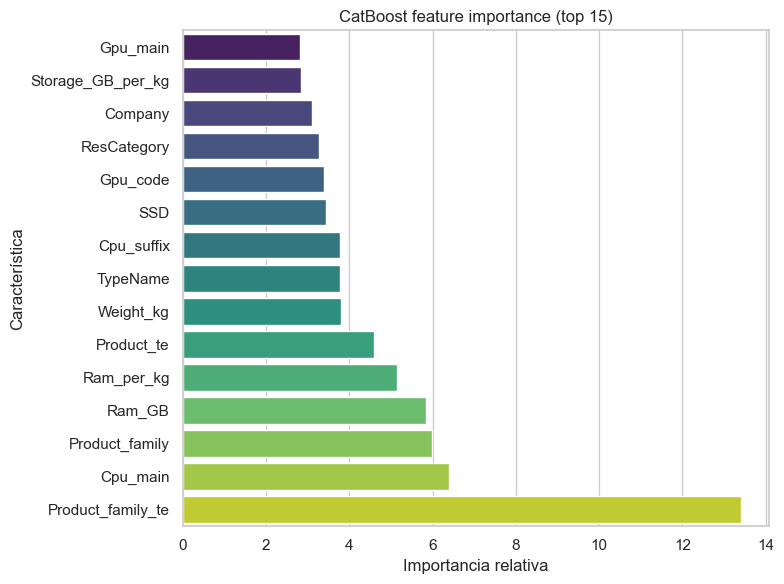

Top 5 características más influyentes:


,feature,importance
0,Product_family_te,13.401323
1,Cpu_main,6.400332
2,Product_family,5.990004
3,Ram_GB,5.841053
4,Ram_per_kg,5.144020


In [25]:
# Diagrama de barras con las características más influyentes
TopN = 15
plot_df = importance_df.head(TopN).sort_values('importance')
plt.figure(figsize=(8, 6))
sns.barplot(data=plot_df, x='importance', y='feature', palette='viridis')
plt.title(f'CatBoost feature importance (top {TopN})')
plt.xlabel('Importancia relativa')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

print('Top 5 características más influyentes:')
display(importance_df.head(5))


## 7. Revisión de la sumisión
Consultamos estadísticas básicas del CSV generado para verificar rangos y media.

In [26]:
# Estadísticas básicas del archivo de envío final
submission['Price_euros'].describe()


count     391.000000
mean     1118.767442
std       629.229824
min       239.425448
25%       635.169451
50%      1017.223819
75%      1499.528163
max      3427.258226
Name: Price_euros, dtype: float64

### Notas finales
- El archivo `submission_catboost.csv` queda listo en la carpeta de trabajo (o `/kaggle/working` en Kaggle).
- Próximos pasos: ampliar el `search_space` o variar seeds si se desea optimizar más.
- Este notebook está pensado para presentación; evita mezclas con LightGBM/XGBoost para mantener la narrativa clara.